<a href="https://www.kaggle.com/code/dinanabb/performance-comparison-with-vs-without-derived-fe?scriptVersionId=346722890" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# **Introduction**

In this notebook, I want to explore whether feature engineering can help improve the performance of our Linear Regression model.

Instead of using only the existing features, we'll try creating a new feature, `Volume`, from the available measurements. Since `Volume` has a strong correlation with our target, `Weight`, it looks like an interesting feature to experiment with.

We'll compare the model's performance before and after adding this derived feature and see whether feature engineering can actually help our predictions.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

In [2]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

In [3]:
df = pd.read_csv('/kaggle/input/datasets/vipullrathod/fish-market/Fish.csv')
df.head(3)

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    object 
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), object(1)
memory usage: 8.8+ KB


# **Deriving Feature**

Let's try using `Volume` as a new feature through feature engineering.

In [5]:
df['Volume'] = df['Length1'] * df['Width'] * df['Height']
df['Volume'].describe()

count     159.000000
mean     1421.512758
std      1267.893948
min        16.940572
25%       413.713963
50%       879.678239
75%      2409.590966
max      4771.551840
Name: Volume, dtype: float64

In [6]:
column_selected = ['Volume', 'Length1', 'Width', 'Height']
target_column = ["Weight"]

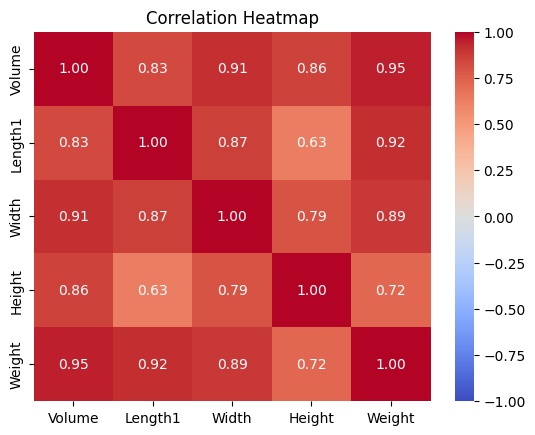

In [7]:
correlation = df[column_selected + target_column].corr()
sns.heatmap(correlation,
           annot=True,
           cmap='coolwarm',
           fmt='.2f',
           vmin=-1,
           vmax=1)
plt.title('Correlation Heatmap')
plt.show()

`Volume` is highly correlated with our target, `Weight`, so this feature looks promising. Let's see how well it performs in our linear regression model.

# **Model**

In [8]:
# log transform
df_log = np.log1p(df[column_selected + target_column])

In [9]:
feature_sets = {
    "Volume Only": ["Volume"],
    "Baseline (Without Volume)": [
        col for col in column_selected
        if col not in ["Volume", target_column]
    ],
    "All Features": column_selected
}

In [10]:
# TRAIN-TEST EXPERIMENT

random_states = range(30)
results = []

for name, features in feature_sets.items():

    for random_state in random_states:

        # -------------------------
        # Train-test split
        # -------------------------
        X_train, X_test, y_train, y_test = train_test_split(
            df_log[features],
            df_log[target_column],
            test_size=0.1,
            random_state=random_state
        )

        # -------------------------
        # Train model
        # -------------------------
        model = LinearRegression()
        model.fit(X_train, y_train)

        # -------------------------
        # Test evaluation
        # -------------------------
        y_test_pred_log = model.predict(X_test)

        # Inverse log transformation
        y_test_pred = np.expm1(y_test_pred_log)
        y_test_original = np.expm1(y_test)

        # Metrics
        test_r2 = r2_score(y_test_original, y_test_pred)
        test_mae = mean_absolute_error(y_test_original, y_test_pred)

        # -------------------------
        # Store results
        # -------------------------
        results.append({
            "Feature Set": name,
            "Random State": random_state,
            "Test R²": test_r2,
            "Test MAE": test_mae
        })


results_df = pd.DataFrame(results)

results_df.style.hide(axis="index")

Feature Set,Random State,Test R²,Test MAE
Volume Only,0,0.922421,70.566754
Volume Only,1,0.966935,35.244884
Volume Only,2,0.775418,88.831464
Volume Only,3,0.945391,55.893386
Volume Only,4,0.963003,49.829358
Volume Only,5,0.782883,88.688247
Volume Only,6,0.915845,71.741733
Volume Only,7,0.929082,48.726520
Volume Only,8,0.911644,78.329356
Volume Only,9,0.733692,82.774038


# **Comparation Results**

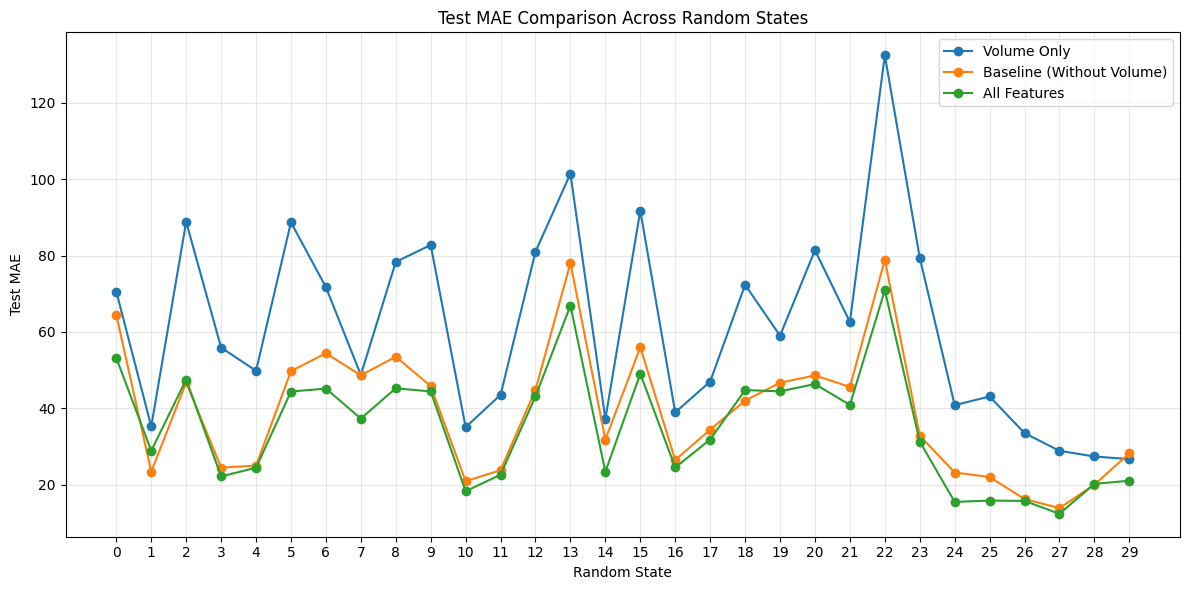

In [11]:
plt.figure(figsize=(12, 6))

for name in feature_sets.keys():
    subset = results_df[results_df["Feature Set"] == name]

    plt.plot(
        subset["Random State"],
        subset["Test MAE"],
        marker="o",
        label=name
    )

plt.xlabel("Random State")
plt.ylabel("Test MAE")
plt.title("Test MAE Comparison Across Random States")
plt.xticks(range(30))
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

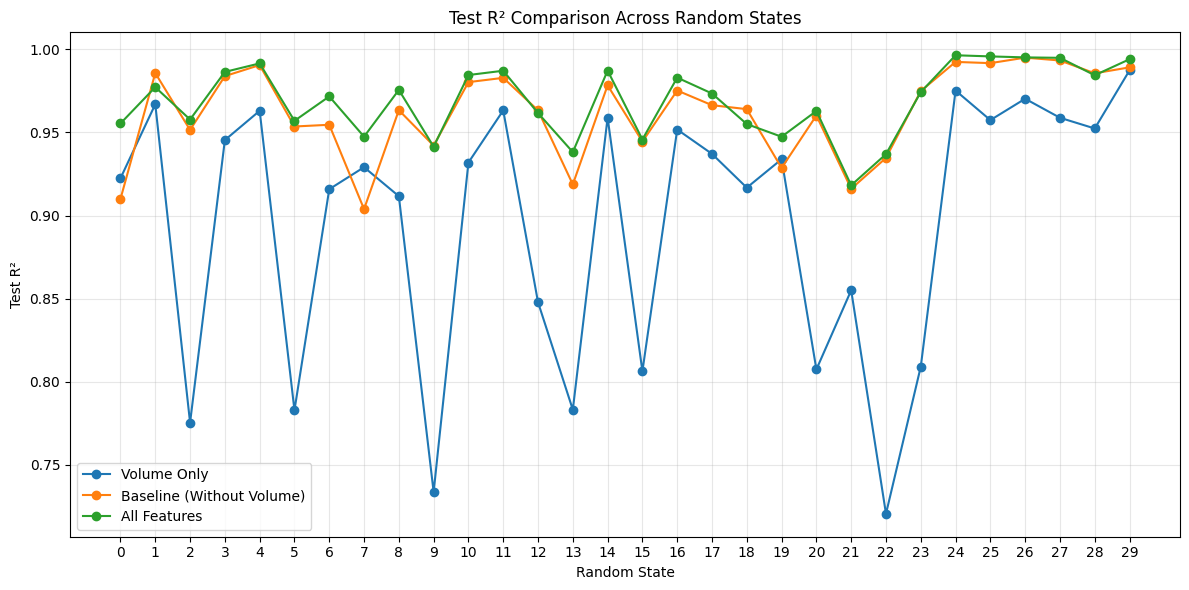

In [12]:
plt.figure(figsize=(12, 6))

for name in feature_sets.keys():
    subset = results_df[results_df["Feature Set"] == name]

    plt.plot(
        subset["Random State"],
        subset["Test R²"],
        marker="o",
        label=name
    )

plt.xlabel("Random State")
plt.ylabel("Test R²")
plt.title("Test R² Comparison Across Random States")
plt.xticks(range(30))
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

From this result, adding the derived feature seems improve our model's predictions. However, it's also worth noting that dropping the original features and keeping only the derived feature doesn't always lead to better predictions.

# **Conclusion**

So, what did we learn?

Adding the derived Volume feature seems to improve our model's prediction performance in this experiment. This suggests that a well-designed derived feature can provide useful information that helps Linear Regression make better predictions.

However, it's also worth noting that replacing the original features with only the derived feature doesn't always lead to better results. Sometimes, keeping both the original and derived features can work better.